In [1]:
# CELL 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
data_path = '../data/raw/'

orders     = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_orders_dataset.csv")
items      = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_order_items_dataset.csv")
customers  = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_customers_dataset.csv")
products   = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_products_dataset.csv")
sellers    = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_sellers_dataset.csv")
reviews    = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_order_reviews_dataset.csv")
payments   = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\olist_order_payments_dataset.csv")
cat_trans  = pd.read_csv(r"C:\Users\Pavitra\Downloads\olist-Project\data\olist_data\product_category_name_translation.csv")

print("Tables loaded:")
for name, df in [('orders', orders), ('items', items), ('customers', customers),('sellers',sellers),
                  ('reviews', reviews), ('payments', payments), ('products', products)]:
    print(f"  {name:15s}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Tables loaded:
  orders         : 99,441 rows × 8 columns
  items          : 112,650 rows × 7 columns
  customers      : 99,441 rows × 5 columns
  sellers        : 3,095 rows × 4 columns
  reviews        : 99,224 rows × 7 columns
  payments       : 103,886 rows × 5 columns
  products       : 32,951 rows × 9 columns


In [3]:
tables=[('orders', orders), ('customers', customers), ('items', items),('sellers',sellers),
                  ('reviews', reviews), ('payments', payments), ('products', products)]
for i in tables:
    print(f"{i[0]} : {i[1].head()}")
    print('/'*100)

orders :                            order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00         

In [4]:
### dropping SEP , 2016 & DEC, 2016 & last two months ogf the dataset 

In [5]:
### checking for date-time columns 

date_time=["order_purchase_timestamp",'order_approved_at','order_delivered_carrier_date','order_delivered_customer_date',
    'order_estimated_delivery_date']

for col in date_time:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')

print("Date columns parsed")
print(f"Orders date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")

Date columns parsed
Orders date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [6]:
### filtering only for the "Delivered" orders as they have a complete transaction journey 

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.merge(customers[['customer_id','customer_unique_id']],on='customer_id',how='left')
print(f"Total orders: {len(orders):,}")
print(f"Delivered orders: {len(delivered):,}")
print(f"Percentage delivered: {len(delivered)/len(orders)*100:.1f}%")
print(delivered.shape)

Total orders: 99,441
Delivered orders: 96,478
Percentage delivered: 97.0%
(96478, 9)


In [7]:
print(delivered.shape)
delivered.head()

(96478, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


In [8]:
print(payments.shape)        # an order can have multiple installments 
payments.head()

(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
payments.groupby("order_id").size().sort_values(ascending=False).head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
dtype: int64

In [10]:
payments_plus = payments.merge(orders[["order_id","order_status"]],on="order_id",how="left")
print(payments_plus.shape)
payments_plus.head()             # an order can have multiple installments 

(103886, 6)


,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,delivered
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,delivered
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,delivered
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,delivered
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,delivered


In [11]:
#  aggregating payments per order id 
# ============================================================
# WHY: as The payments table has multiple rows per order (one per payment installment
#      or payment method). We want ONE payment amount per order for analysis.
#      Using sum() aggregates multiple payment rows correctly.

payments_agg = payments_plus[payments_plus["order_status"]=="delivered"].groupby('order_id').agg(
   {'payment_value':'sum'}
).reset_index()


print(f"Payments rows before agg: {len(payments):,}")
print(f"Payments rows after agg:  {len(payments_agg):,}")

Payments rows before agg: 103,886
Payments rows after agg:  96,477


In [12]:
payments_agg.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [13]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
items_delivered = items.copy()

items_delivered = items_delivered.merge(
    orders[['order_id', 'order_status']],
    on='order_id',
    how='left'
)

items_delivered = items_delivered[
    items_delivered['order_status'] == 'delivered'      # ensures only the delivered order's items are being counted 
]

print(items_delivered.shape)
items_delivered.head()

(110197, 8)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,delivered


In [15]:
items_delivered["order_item_id"].value_counts()      ### because many orders contain multiple products. 

order_item_id
1     96478
2      9635
3      2243
4       937
5       442
6       249
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [16]:
### adding the products at item level - 1:1 merege on product_id

items_delivered = items_delivered.merge(products[['product_id', 'product_category_name']],
                                        on='product_id', how='left')


In [17]:
### adjusting items to order - level 

items_agg = items_delivered.groupby('order_id').agg(num_items=('order_item_id', 'count'),
item_revenue=('price', 'sum'),avg_item_price=('price', 'mean'),total_freight=('freight_value', 'sum'),
category=('product_category_name', lambda x: x.mode()[0] if len(x.dropna()) > 0 else 'unknown')).reset_index()
# now we have all rows in the items_delivered table aggregated at order- level 

In [18]:
print(items_agg.shape) 

(96478, 6)


In [19]:

print(items_agg.shape)
items_agg.head()

(96478, 6)


,order_id,num_items,item_revenue,avg_item_price,total_freight,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,18.14,ferramentas_jardim


In [20]:
items_agg['num_items'].unique()

array([ 1,  2,  3,  4,  5,  6,  8,  7, 20, 12, 10, 13, 15, 11, 14, 21,  9])

In [21]:
### building the master dataframe

master = delivered[['order_id', 'customer_id', 'customer_unique_id','order_status','order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date']].copy()
master=master.merge(items_agg, on='order_id', how='left')
print(master.shape)

master.head()

(96478, 12)


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria


In [22]:
master.groupby('customer_unique_id')["customer_id"].count().unique()  # the same customer_unique_id can have multiple ordders with different customer_id's

array([ 1,  2,  3,  4,  6,  7,  5,  9, 15])

In [23]:
master.groupby('customer_unique_id')["order_id"].count().unique() # the same customer_unique_id can have multiple ordders with different customer_id's

array([ 1,  2,  3,  4,  6,  7,  5,  9, 15])

In [24]:
payments_agg.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [25]:
items_agg.head()

,order_id,num_items,item_revenue,avg_item_price,total_freight,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,18.14,ferramentas_jardim


In [26]:
# Adding payment info 

master = master.merge(payments_agg, on='order_id', how='left')
print(f"After payments merge: {master.shape}")


master.head()

After payments merge: (96478, 13)


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62


In [27]:
### Adding customer_info.

master=master.merge(customers[["customer_id","customer_city","customer_state"]],on='customer_id',how="left")
print(f"After customers merge: {master.shape}")

master.head()       

After customers merge: (96478, 15)


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP


In [28]:
print(f"After customers merge: {master.shape}")
print(f"\nMaster table: {master.shape[0]:,} orders × {master.shape[1]} columns")
print(f"Null counts:\n{master.isnull().sum()}")

After customers merge: (96478, 15)

Master table: 96,478 orders × 15 columns
Null counts:
order_id                         0
customer_id                      0
customer_unique_id               0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
num_items                        0
item_revenue                     0
avg_item_price                   0
total_freight                    0
category                         0
payment_value                    1
customer_city                    0
customer_state                   0
dtype: int64


In [29]:
master['expected_payment'] = master['item_revenue'] + master['total_freight']
master["diff"] = (master['payment_value'] - master['expected_payment']).abs()
print(master["diff"].describe())

count    96477.000000
mean         0.033511
std          1.138591
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: diff, dtype: float64


In [30]:
master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,expected_payment,diff
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP,38.71,0.000000e+00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA,141.46,0.000000e+00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO,179.12,0.000000e+00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN,72.20,0.000000e+00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP,28.62,3.552714e-15


In [31]:
# orders with significant diff

master.sort_values('diff', ascending=False)[['order_id','payment_value','item_revenue','total_freight','expected_payment','diff']
].head(20)

,order_id,payment_value,item_revenue,total_freight,expected_payment,diff
11458,ce6d150fb29ada17d2082f4847107665,1586.47,1299.00,104.66,1403.66,182.81
47235,6e5fe7366a2e1bfbf3257dba0af1267f,406.92,179.19,108.72,287.91,119.01
68752,70b742795bc441e94a44a084b6d9ce7a,578.82,269.99,196.94,466.93,111.89
32174,996c7e73600ad3723e8627ab7bef81e4,664.43,559.90,28.00,587.90,76.53
51423,70b7e94ea46d3e8b5bc12a50186edaf0,274.84,167.88,45.27,213.15,61.69
82872,bc2c82b0ef78d2252b6176d1972db7c9,303.02,165.00,77.01,242.01,61.01
91499,af9ffff2ce6b3defd34fd4c78857a379,466.97,395.65,17.52,413.17,53.80
30725,262118ce178bb3e4590a3adcf6d62e6b,126.12,119.80,57.94,177.74,51.62
66757,bfdb5bbb06458d600a33d61f5f287472,394.36,297.00,51.93,348.93,45.43
8310,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,293.89,209.80,44.65,254.45,39.44


In [32]:
### finding the percentage of orders with significant diff (>1)

for t in [0.5, 1, 5, 10, 50, 100]:
    n = (master['diff'] > t).sum()
    pct = n / len(master) * 100
    print(f"diff > {t:>5}: {n:>6} orders ({pct:.3f}%)")    
    
    # shows that 523 orders (0.542% ) have diff > 1 (i.e. not rounding - off error)
    # therefore , >99.4% orders pass the payment sanity check

diff >   0.5:    251 orders (0.260%)
diff >     1:    246 orders (0.255%)
diff >     5:    169 orders (0.175%)
diff >    10:     97 orders (0.101%)
diff >    50:      8 orders (0.008%)
diff >   100:      3 orders (0.003%)


In [33]:
master.drop(columns=['expected_payment', 'diff'], inplace=True)

In [34]:
master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP


In [35]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   customer_unique_id             96478 non-null  object        
 3   order_status                   96478 non-null  object        
 4   order_purchase_timestamp       96478 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 7   num_items                      96478 non-null  int64         
 8   item_revenue                   96478 non-null  float64       
 9   avg_item_price                 96478 non-null  float64       
 10  total_freight                  96478 non-null  float64       
 11  category       

In [36]:
### making a seperate reviews table 

reviews_master = reviews.merge(orders[["order_id","order_status"]],on='order_id',how='left')
print(reviews_master['order_status'].unique())
reviews_master.head()

['delivered' 'canceled' 'shipped' 'processing' 'unavailable' 'invoiced'
 'created' 'approved']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_status
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,delivered
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,delivered
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,delivered
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,delivered
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,delivered


In [37]:
print(reviews_master["order_status"].isna().sum())

0


In [38]:
reviews_master.loc[
    reviews_master["order_status"] == "delivered"
].shape

(96361, 8)

In [39]:
reviews_master.groupby("order_id")["review_id"].nunique().sum()

# ~96,478 orders and 99,224 reviews
# this shows that a single order can have multiple reviews , so we take the latest review for that order

np.int64(99224)

In [40]:
reviews_master["order_status"].value_counts()  
# so some orders still have reviews which were ultimately not delivered 

order_status
delivered      96361
shipped         1043
canceled         609
unavailable      597
invoiced         313
processing       296
created            3
approved           2
Name: count, dtype: int64

In [41]:
reviews_master[
    reviews_master["order_status"] != "delivered"
]["order_status"].value_counts()

order_status
shipped        1043
canceled        609
unavailable     597
invoiced        313
processing      296
created           3
approved          2
Name: count, dtype: int64

In [42]:
reviews_master["order_status"].unique()

array(['delivered', 'canceled', 'shipped', 'processing', 'unavailable',
       'invoiced', 'created', 'approved'], dtype=object)

In [43]:
reviews_master = reviews_master[reviews_master["order_status"]=="delivered"]
reviews_master["order_status"].unique()

array(['delivered'], dtype=object)

In [44]:

reviews_agg = reviews_master.sort_values('review_creation_date').groupby('order_id').agg(
    review_score=('review_score', 'last'))

print(f"Reviews rows: {len(reviews):,} → aggregated to {len(reviews_agg):,}")

Reviews rows: 99,224 → aggregated to 95,832


In [45]:
reviews_agg = reviews_agg.reset_index()
reviews_agg

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5
1,00018f77f2f0320c557190d7a144bdd3,4
2,000229ec398224ef6ca0657da4fc703e,5
3,00024acbcdf0a6daa1e931b038114c75,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,5
...,...,...
95827,fffc94f6ce00a00581880bf54a75a037,5
95828,fffcd46ef2263f404302a634eb57f7eb,5
95829,fffce4705a9662cd70adb13d4a31832d,5
95830,fffe18544ffabc95dfada21779c9644f,5


In [46]:
master

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,2017-03-17 15:08:01,2017-03-28,1,72.00,72.00,13.08,beleza_saude,85.08,sao jose dos campos,SP
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,1,174.90,174.90,20.10,bebes,195.00,praia grande,SP
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,1,205.99,205.99,65.02,eletrodomesticos_2,271.01,nova vicosa,BA
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,2,359.98,179.99,81.18,informatica_acessorios,441.16,japuiba,RJ


In [47]:
### joining the reviews_master to master (note : an order can have multiple reviews)

master = master.merge(reviews_agg[["order_id","review_score"]],on="order_id",how="left")
master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP,5.0


In [48]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   customer_unique_id             96478 non-null  object        
 3   order_status                   96478 non-null  object        
 4   order_purchase_timestamp       96478 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 7   num_items                      96478 non-null  int64         
 8   item_revenue                   96478 non-null  float64       
 9   avg_item_price                 96478 non-null  float64       
 10  total_freight                  96478 non-null  float64       
 11  category       

## Data Cleaning 

In [49]:
master[master["order_status"]!="delivered"]

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score


### handlinf missing values 

In [50]:
# order_delivered_customer_date = 8 orders do not have this value 

master[master["order_delivered_customer_date"].isna()]

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score
2921,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,13467e882eb3a701826435ee4424f2bd,delivered,2017-11-28 17:44:07,NaT,2017-12-18,1,117.30,117.30,17.53,automotivo,134.83,cerquilho,SP,5.0
20021,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,2f17c5b324ad603491521b279a9ff4de,delivered,2018-06-20 06:58:43,NaT,2018-07-16,1,329.00,329.00,25.24,industria_comercio_e_negocios,354.24,quadra,SP,5.0
42530,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,1bd06a0c0df8b23dacfd3725d2dc0bb9,delivered,2018-07-01 17:05:11,NaT,2018-07-30,1,139.00,139.00,19.07,relogios_presentes,158.07,pindamonhangaba,SP,5.0
76909,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,3bc508d482a402715be4d5cf4020cc81,delivered,2018-07-01 22:05:55,NaT,2018-07-30,1,139.00,139.00,19.07,relogios_presentes,158.07,sumare,SP,5.0
80392,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,ebf7e0d43a78c81991a4c59c145c75db,delivered,2018-07-01 21:14:02,NaT,2018-07-24,1,188.99,188.99,15.63,brinquedos,204.62,sao carlos,SP,5.0
89883,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,d77cf4be2654aa70ef150f8bfec076a6,delivered,2017-05-25 23:22:43,NaT,2017-06-23,1,179.00,179.00,15.00,esporte_lazer,194.00,porto alegre,RS,5.0
94731,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,cce5e8188bf42ffb3bb5b18ff58f5965,delivered,2018-06-08 12:09:39,NaT,2018-06-26,1,110.99,110.99,9.13,informatica_acessorios,120.12,guarulhos,SP,1.0
95117,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,175378436e2978be55b8f4316bce4811,delivered,2018-06-27 16:09:12,NaT,2018-07-19,1,45.90,45.90,9.07,livros_interesse_geral,54.97,ribeirao pires,SP,5.0


In [51]:
master[master["order_delivered_customer_date"].isna()]["payment_value"].unique()

array([134.83, 354.24, 158.07, 204.62, 194.  , 120.12,  54.97])

In [52]:
v=[0.25,0.50,0.75,0.90]
for i in v:
    print(f"percentile {i} : {master["payment_value"].quantile(i)}")

percentile 0.25 : 61.88
percentile 0.5 : 105.28
percentile 0.75 : 176.33
percentile 0.9 : 305.9740000000001


In [53]:
master[master["order_delivered_customer_date"].isna()]["review_score"].value_counts()

review_score
5.0    7
1.0    1
Name: count, dtype: int64

In [54]:
### since very small number of orders have no value here and 7 out of 8 of them have 5 as review_score ,so 


''' This suggests :
7 of the 8 customers gave a 5-star review, which strongly suggests they actually received the product.
The missing order_delivered_customer_date is likely a data entry / logging issue, not a genuinely undelivered order.'''

# im dropping these 8 rows 

master.dropna(subset=["order_delivered_customer_date"], inplace=True)

In [55]:
### payment_value 

master.loc[master["payment_value"].isna()]

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,delivered,2016-09-15 12:16:38,2016-11-09 07:47:38,2016-10-04,3,134.97,44.99,8.49,beleza_saude,NaN,sao joaquim da barra,SP,1.0


In [56]:
master.loc[master["payment_value"].isna(),"payment_value"] = (master["item_revenue"] + master["total_freight"])
# imputing with item_revenue + total_freight

In [57]:

master.loc[master["payment_value"].isna()]

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score


In [58]:
### review_score 

master.loc[master["review_score"].isna()]   # there are 646 orders with no reviews

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score
15,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,6e26bbeaa107ec34112c64e1ee31c0f5,delivered,2018-01-02 19:00:43,2018-01-20 01:38:59,2018-02-06,1,1299.00,1299.00,77.45,construcao_ferramentas_construcao,1376.45,rio de janeiro,RJ,NaN
301,4906eeadde5f70b308c20c4a8f20be02,4e7656e34357b93f14b40c6400ca3f6e,ea870f4fdfd85ac98ab775b76efe3143,delivered,2017-12-08 04:45:26,2018-01-09 18:04:58,2018-01-03,1,144.99,144.99,17.26,cool_stuff,162.25,rio de janeiro,RJ,NaN
369,b7a4a9ecb1cd3ef6a3e36a48e200e3be,c3d8fc500d86b1c961ee144395c13a57,367f4686d7112d69feed92b02a1775ed,delivered,2017-05-19 18:13:54,2017-06-08 07:53:42,2017-06-16,1,26.00,26.00,15.10,moveis_decoracao,41.10,lages,SC,NaN
377,59b32faedc12322c672e95ec3716d614,5baa82a2c45fa3220cb57d9881db3211,c56d066e503008b8d0bf4204857c588d,delivered,2018-06-27 11:10:11,2018-07-06 16:37:36,2018-07-26,1,69.00,69.00,18.58,relogios_presentes,87.58,santa maria,RS,NaN
395,c2215076050fa358934105b15c34cf3b,19e7a88b34ef70d108e660c6eb33e82a,f329e0e1d8897ffa466a836ed216a23b,delivered,2017-07-16 10:04:36,2017-07-26 20:32:17,2017-08-04,1,89.90,89.90,12.13,cama_mesa_banho,102.03,sao paulo,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95756,0c384d67524b5b92aa2fa6c8baa9a983,53421895d40d7df28d68c22ffa043355,2f3aabaf3f5d1e8a6c49ac2fdee3cf3e,delivered,2017-06-05 19:20:11,2017-06-13 14:09:21,2017-06-27,1,89.90,89.90,12.13,cama_mesa_banho,102.03,guarulhos,SP,NaN
95838,906a6b0a96d89ee226e4977e99b80b9e,274a720e69d300bc7696c8570f8978fe,e2226f481eef03f2876d1a27f0f4b1b0,delivered,2017-08-28 15:14:21,2017-09-05 19:47:44,2017-09-18,1,79.90,79.90,12.06,moveis_sala,91.96,santos,SP,NaN
96059,5333db16fe357175d39c82840dd3269d,7e008e5ec21e044fe30c34ec4e9d0747,d06f106a141c540ca3b3cc0a3a8bba39,delivered,2018-03-10 18:18:20,2018-04-03 15:32:52,2018-03-29,2,107.78,53.89,30.52,consoles_games,138.30,sao paulo,SP,NaN
96182,2f2df159f26ddb73d55ee72372200d3e,86a7245fffe6a418ca1658a13ecc4531,1d532194f005426adcdf6d969640d56e,delivered,2017-07-17 01:19:50,2017-07-26 09:44:00,2017-08-09,1,150.00,150.00,16.81,eletronicos,166.81,conselheiro pena,MG,NaN


In [59]:
master[master["review_score"].isna()]["payment_value"].describe()     
# this shows that more than 50% of the orders that did not have a review score have made a purchase greater than the median value 
# of the overall payment_value , this suggest that the customers who are making these orders are valuable to the buisness. 

count     646.000000
mean      198.809102
std       362.194009
min        16.290000
25%        69.195000
50%       117.395000
75%       204.410000
max      6922.210000
Name: payment_value, dtype: float64

In [60]:
master[master["review_score"].isna()]["payment_value"].value_counts()

payment_value
102.03    5
32.38     3
53.10     3
102.74    2
153.90    2
         ..
131.16    1
117.85    1
91.96     1
138.30    1
235.12    1
Name: count, Length: 611, dtype: int64

In [61]:
## leaving the missing rows for review_score as it is , later will make a flag for missing_review 

In [62]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 96477
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   customer_unique_id             96470 non-null  object        
 3   order_status                   96470 non-null  object        
 4   order_purchase_timestamp       96470 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 7   num_items                      96470 non-null  int64         
 8   item_revenue                   96470 non-null  float64       
 9   avg_item_price                 96470 non-null  float64       
 10  total_freight                  96470 non-null  float64       
 11  category            

### handling delivery time columns 

In [63]:
### making to date-time 

master['delivery_days'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

master['estimated_days'] = (
    master['order_estimated_delivery_date'] - master['order_purchase_timestamp']
).dt.days

# On-time delivery flag: actual <= estimated
master['on_time_delivery'] = (master['delivery_days'] <= master['estimated_days']).astype(int)


In [64]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 96477
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   customer_unique_id             96470 non-null  object        
 3   order_status                   96470 non-null  object        
 4   order_purchase_timestamp       96470 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 7   num_items                      96470 non-null  int64         
 8   item_revenue                   96470 non-null  float64       
 9   avg_item_price                 96470 non-null  float64       
 10  total_freight                  96470 non-null  float64       
 11  category            

In [65]:
master[master["delivery_days"]<0]  # no data entry problem

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score,delivery_days,estimated_days,on_time_delivery


In [66]:
master[master["delivery_days"]>120].count()   # 43 orders were delivered after 120 days after being ordered

order_id                         43
customer_id                      43
customer_unique_id               43
order_status                     43
order_purchase_timestamp         43
order_delivered_customer_date    43
order_estimated_delivery_date    43
num_items                        43
item_revenue                     43
avg_item_price                   43
total_freight                    43
category                         43
payment_value                    43
customer_city                    43
customer_state                   43
review_score                     41
delivery_days                    43
estimated_days                   43
on_time_delivery                 43
dtype: int64

In [67]:
master[master["delivery_days"].isna()]["on_time_delivery"]

Series([], Name: on_time_delivery, dtype: int64)

In [68]:
v=[0.25,0.50,0.75,0.90]
for i in v:
    print(f"percentile {i} : {master["delivery_days"].quantile(i)}")    # this shows the delivery day distribution for the delivered orders

percentile 0.25 : 6.0
percentile 0.5 : 10.0
percentile 0.75 : 15.0
percentile 0.9 : 23.0


In [69]:
master.loc[master["delivery_days"] > 120][["delivery_days", "review_score", "payment_value"]].describe()

,delivery_days,review_score,payment_value
count,43.000000,41.000000,43.000000
mean,162.023256,3.000000,291.189302
std,25.656604,1.658312,401.792905
min,124.000000,1.000000,41.780000
25%,138.000000,1.000000,84.935000
50%,167.000000,4.000000,185.020000
75%,186.500000,4.000000,303.315000
max,209.000000,5.000000,2092.860000


In [70]:
### They represent a small but real group of customers who experienced exceptionally long delivery times. 
### Since they have valid review scores and payment values, they provide insight into rare but important potential logistics cases.
### keeping them as it is for now , will use tree model which handle these type of outliers well or 
### can create a new feature "extreme delay" feature

In [71]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 96477
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   customer_unique_id             96470 non-null  object        
 3   order_status                   96470 non-null  object        
 4   order_purchase_timestamp       96470 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 7   num_items                      96470 non-null  int64         
 8   item_revenue                   96470 non-null  float64       
 9   avg_item_price                 96470 non-null  float64       
 10  total_freight                  96470 non-null  float64       
 11  category            

In [72]:
master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score,delivery_days,estimated_days,on_time_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP,4.0,8,15,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA,4.0,13,19,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO,5.0,9,26,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN,5.0,13,26,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP,5.0,2,12,1


## Bit of EDA

In [73]:
master["payment_value"].max()

np.float64(13664.08)

In [74]:
master["payment_value"].min()

np.float64(9.59)

In [75]:
master["payment_value"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25      61.8800
0.50     105.2800
0.75     176.3300
0.90     305.9710
0.95     446.3330
0.99    1052.4003
Name: payment_value, dtype: float64

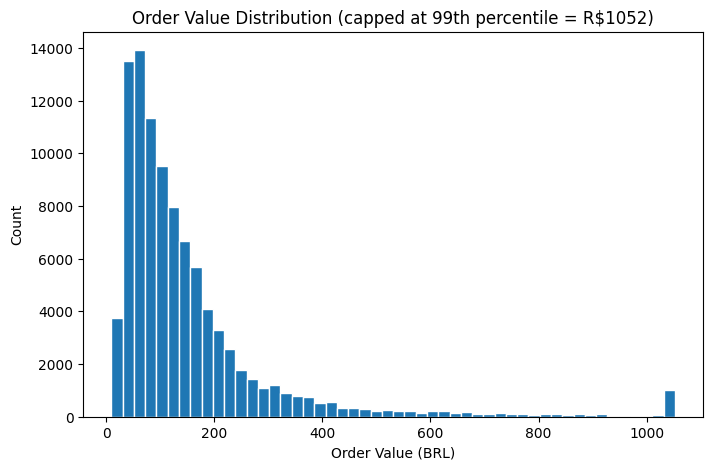

In [76]:

#  ORDER VALUE & REVIEW SCORE DISTRIBUTION

p99 = master["payment_value"].quantile(0.99)     # showing the first 99th percentile order value

plt.figure(figsize=(8,5))
plt.hist(master["payment_value"].clip(upper=p99),bins=50,edgecolor="white")

plt.title(f"Order Value Distribution (capped at 99th percentile = R${p99:.0f})")
plt.xlabel("Order Value (BRL)")
plt.ylabel("Count")
plt.savefig("Order Value Distribution (capped at 99th percentile)")
plt.show()

In [77]:
master[master["payment_value"]>1052]["payment_value"].count()  # shows a significant number of customers 967 are amongst 99 percentile order value 

np.int64(967)

In [78]:
master[master["payment_value"]>1052]["payment_value"].value_counts()

payment_value
1479.51    7
1250.81    5
1471.51    5
1118.05    4
1338.51    4
          ..
1214.65    1
1500.19    1
1480.73    1
1255.43    1
1376.45    1
Name: count, Length: 859, dtype: int64

In [79]:
high_value_purchase_amounts = sorted(master[master["payment_value"]>1052]["payment_value"].unique())
high_value_purchase_amounts    # only 1 order is above 13000 and only 17 orders above 4000

[np.float64(1052.14),
 np.float64(1052.36),
 np.float64(1052.49),
 np.float64(1053.74),
 np.float64(1053.84),
 np.float64(1054.63),
 np.float64(1055.86),
 np.float64(1055.92),
 np.float64(1057.2),
 np.float64(1057.29),
 np.float64(1057.4),
 np.float64(1057.88),
 np.float64(1058.1),
 np.float64(1058.78),
 np.float64(1059.25),
 np.float64(1061.52),
 np.float64(1061.56),
 np.float64(1061.76),
 np.float64(1063.09),
 np.float64(1063.75),
 np.float64(1066.08),
 np.float64(1066.86),
 np.float64(1068.5),
 np.float64(1069.04),
 np.float64(1069.22),
 np.float64(1069.41),
 np.float64(1070.68),
 np.float64(1070.74),
 np.float64(1071.1),
 np.float64(1071.12),
 np.float64(1072.41),
 np.float64(1072.59),
 np.float64(1075.12),
 np.float64(1075.23),
 np.float64(1075.56),
 np.float64(1075.74),
 np.float64(1075.83),
 np.float64(1076.45),
 np.float64(1076.76),
 np.float64(1077.41),
 np.float64(1078.43),
 np.float64(1078.92),
 np.float64(1079.71),
 np.float64(1079.75),
 np.float64(1079.98),
 np.float64(108

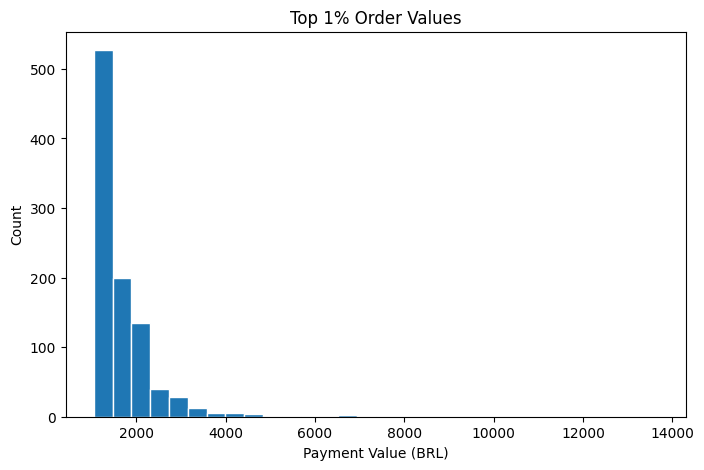

In [80]:
### seperate for p99 to p100



top_1pct = master[master["payment_value"] >= p99]

plt.figure(figsize=(8,5))

plt.hist(top_1pct["payment_value"], bins=30, edgecolor="white")

plt.title("Top 1% Order Values")
plt.xlabel("Payment Value (BRL)")
plt.ylabel("Count")
plt.savefig("Top 1% Order Values Distribution")

plt.show()

1. Interpretation of the Order Value Distribution
What the chart shows

-Most orders are low to medium value.
-The majority of customers spend roughly R$50–R$250 per order.
-As order value increases, the number of orders drops sharply.
-The distribution is heavily right-skewed: a small number of customers place very expensive orders.

Top 1% Orders
-The 99th percentile starts around R$1052.
-Only 967 orders (about 1% of all delivered orders) fall into this group.
- 1 order exceed R$13,000, which is more than 10× the 99th percentile threshold.
-Even within the top 1% , most orders are concentrated near the lower end (around R$1000–R$2500), with only a handful of extreme purchases.

2. The business has two different customer groups
-Regular customers making smaller purchases.
-Premium customers making very large purchases.

These groups should not be treated the same way.

3. Ultra-high-value orders are rare

-Orders above R$5000 are very uncommon.
-Orders above R$10,000 are exceptionally rare.
-Losing even a few of these customers could have a noticeable impact on revenue.

5. Recommendations

-Create a VIP customer segment for customers spending above the 99th percentile.
-Target Premium customers (R$1000–2500) with upselling campaigns since theyre the largest group within the top 1%.
-Protect Ultra-VIP customers (>R$5000) with priority support and personalized offers.
-Analyze the few extreme orders (>R$5000) to identify products and customer profiles that drive exceptional revenue.
-Focus on moving customers from mid-value orders into the Premium segment, since this group is much larger than the Ultra-VIP segment and offers greater growth potential.

In [81]:
master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score,delivery_days,estimated_days,on_time_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,29.99,29.99,8.72,utilidades_domesticas,38.71,sao paulo,SP,4.0,8,15,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,118.70,118.70,22.76,perfumaria,141.46,barreiras,BA,4.0,13,19,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,159.90,159.90,19.22,automotivo,179.12,vianopolis,GO,5.0,9,26,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,45.00,45.00,27.20,pet_shop,72.20,sao goncalo do amarante,RN,5.0,13,26,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,19.90,19.90,8.72,papelaria,28.62,santo andre,SP,5.0,2,12,1


In [82]:
### investigating further into the 99th+ (p99 to p100) percentile customers 

p99_plus_master = master[master["payment_value"]>p99]

p99_plus_master.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,num_items,item_revenue,avg_item_price,total_freight,category,payment_value,customer_city,customer_state,review_score,delivery_days,estimated_days,on_time_delivery
15,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,6e26bbeaa107ec34112c64e1ee31c0f5,delivered,2018-01-02 19:00:43,2018-01-20 01:38:59,2018-02-06,1,1299.0,1299.0,77.45,construcao_ferramentas_construcao,1376.45,rio de janeiro,RJ,NaN,17,34,1
321,2b72a32a2c3e93fa260ca7655073886f,5265029daa29cc08d86b9f96cd99d03f,6940ba069c2c25350ea9e059b35d7d23,delivered,2018-04-18 15:40:36,2018-05-03 13:03:03,2018-05-18,1,1148.0,1148.0,107.43,eletrodomesticos_2,1255.43,garuva,SC,5.0,14,29,1
330,ac64f79a33bfa575fc5a17e7926df3d5,51a8d592336a414fea21f12534b0f797,5a6d092525ea183026c9b405b903fe0c,delivered,2018-04-01 18:27:01,2018-04-04 19:47:44,2018-04-12,1,1099.0,1099.0,20.60,eletroportateis,1119.60,sao paulo,SP,3.0,3,10,1
334,6cb134bb285a64b0425d1fdaa00d4214,d854800a320bbb07b484f76894e4638f,a813e96ecd044395587037a8314a4151,delivered,2018-07-01 20:54:21,2018-07-10 22:12:13,2018-07-26,1,1999.0,1999.0,32.09,relogios_presentes,2031.09,arapongas,PR,5.0,9,24,1
393,da8be3bb62e9bf01e2e1a3bfd74ebd1a,3f083b9f62e687be8d84684c7d54c8db,1e7097be947ad5d0f7819bdc9d8d7d0e,delivered,2017-04-06 13:44:08,2017-05-08 10:52:06,2017-05-04,1,2690.0,2690.0,61.24,ferramentas_jardim,2751.24,sao goncalo,RJ,1.0,31,27,0


In [83]:
k= ["category","review_score","on_time_delivery"]
for i in k:
    print(f"{i} : {p99_plus_master[i].unique()}")
    print("/"*50)

category : ['construcao_ferramentas_construcao' 'eletrodomesticos_2'
 'eletroportateis' 'relogios_presentes' 'ferramentas_jardim'
 'esporte_lazer' 'beleza_saude' 'cool_stuff' 'telefonia' 'cama_mesa_banho'
 'pcs' 'portateis_casa_forno_e_cafe' 'consoles_games'
 'instrumentos_musicais' 'artes' 'automotivo' 'utilidades_domesticas'
 'agro_industria_e_comercio' 'informatica_acessorios'
 'moveis_cozinha_area_de_servico_jantar_e_jardim' 'brinquedos'
 'moveis_decoracao' 'construcao_ferramentas_seguranca' 'malas_acessorios'
 'eletrodomesticos' 'eletronicos' 'construcao_ferramentas_iluminacao'
 'bebes' 'industria_comercio_e_negocios' 'telefonia_fixa'
 'moveis_escritorio' 'casa_construcao' 'pet_shop'
 'sinalizacao_e_seguranca' 'musica' 'unknown' 'moveis_sala'
 'moveis_quarto' 'climatizacao' 'bebidas' 'papelaria'
 'fashion_bolsas_e_acessorios' 'construcao_ferramentas_ferramentas'
 'audio' 'dvds_blu_ray' 'market_place'
 'portateis_cozinha_e_preparadores_de_alimentos']
///////////////////////////////

In [84]:
p99_plus_master['review_score'].value_counts() 

review_score
5.0    546
4.0    177
1.0    146
3.0     49
2.0     34
Name: count, dtype: int64

* out of 967 high value customers , about 723 customers have left a 4 or 4+ rating 
* this indicates that about 76% of them are satisfied
* can invstigate further into the ones who gave <4 ratings as these are high value customers

In [85]:
p99_plus_master[p99_plus_master["review_score"]>=4]["category"].value_counts()  
                      

category
pcs                                               93
beleza_saude                                      87
relogios_presentes                                70
informatica_acessorios                            45
esporte_lazer                                     43
ferramentas_jardim                                39
instrumentos_musicais                             38
eletroportateis                                   33
automotivo                                        31
eletrodomesticos_2                                24
bebes                                             23
utilidades_domesticas                             20
construcao_ferramentas_construcao                 20
telefonia                                         14
cama_mesa_banho                                   14
eletrodomesticos                                  12
cool_stuff                                        10
moveis_decoracao                                  10
moveis_escritorio                    

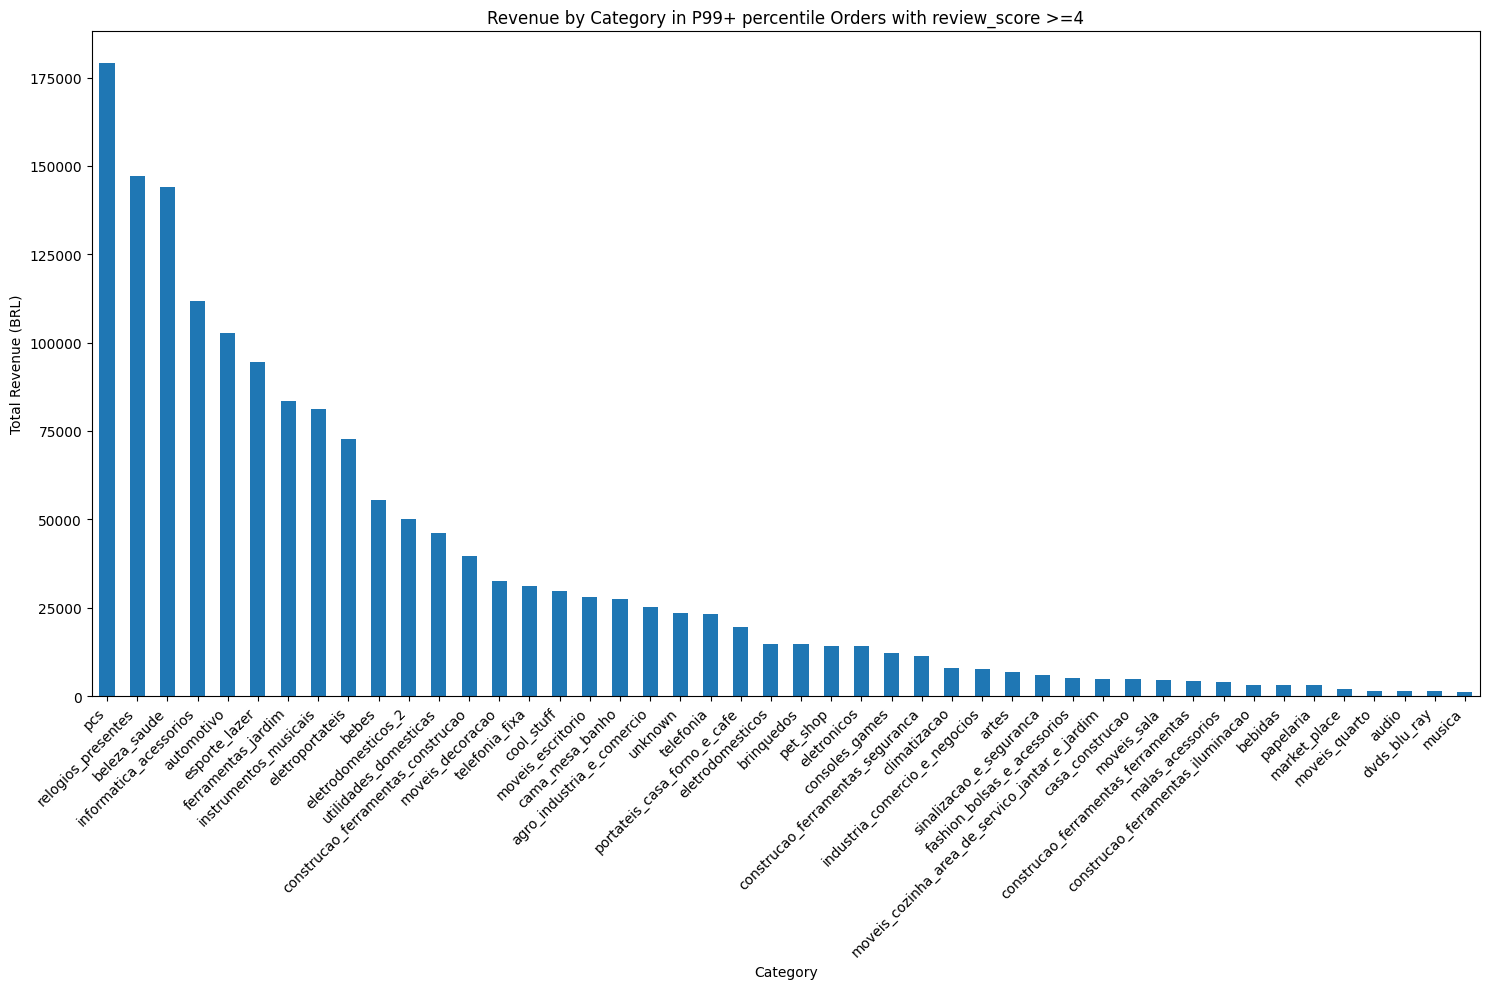

In [86]:
top_category = list(p99_plus_master[p99_plus_master["review_score"]>=4]["category"])

category_revenue = (p99_plus_master[p99_plus_master["category"].isin(top_category)].groupby("category")["payment_value"].sum()
    .sort_values(ascending=False))

plt.figure(figsize=(15, 10))
category_revenue.plot(kind="bar")

plt.title("Revenue by Category in P99+ percentile Orders with review_score >=4")
plt.xlabel("Category")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Revenue by Category in P99+ percentile Orders with high review_score")

plt.show()

In [87]:
### total revenue generated by 99 percentile orders with review_score >= 4

revenue_review_high =p99_plus_master[p99_plus_master["review_score"]>=4]["payment_value"].sum()
count_review_high = p99_plus_master[p99_plus_master["review_score"]>=4]["payment_value"].count()

print(f" revenue for high value , high review orders : {revenue_review_high: .0f} and count of high value , high review orders : {count_review_high}")

 revenue for high value , high review orders :  1179770 and count of high value , high review orders : 723


In [88]:
print(f" average revenue for high value , low review orders : {revenue_review_high/count_review_high:.0f}")

 average revenue for high value , low review orders : 1632


In [89]:
## now same for review_score < 4

p99_plus_master[p99_plus_master["review_score"]<4]["category"].value_counts()  
                      

category
automotivo                                        28
relogios_presentes                                20
informatica_acessorios                            18
pcs                                               16
esporte_lazer                                     15
beleza_saude                                      13
bebes                                             13
moveis_decoracao                                  12
moveis_escritorio                                 10
ferramentas_jardim                                 9
eletroportateis                                    8
agro_industria_e_comercio                          7
instrumentos_musicais                              7
utilidades_domesticas                              7
cool_stuff                                         5
eletrodomesticos_2                                 4
telefonia_fixa                                     4
construcao_ferramentas_construcao                  4
cama_mesa_banho                      

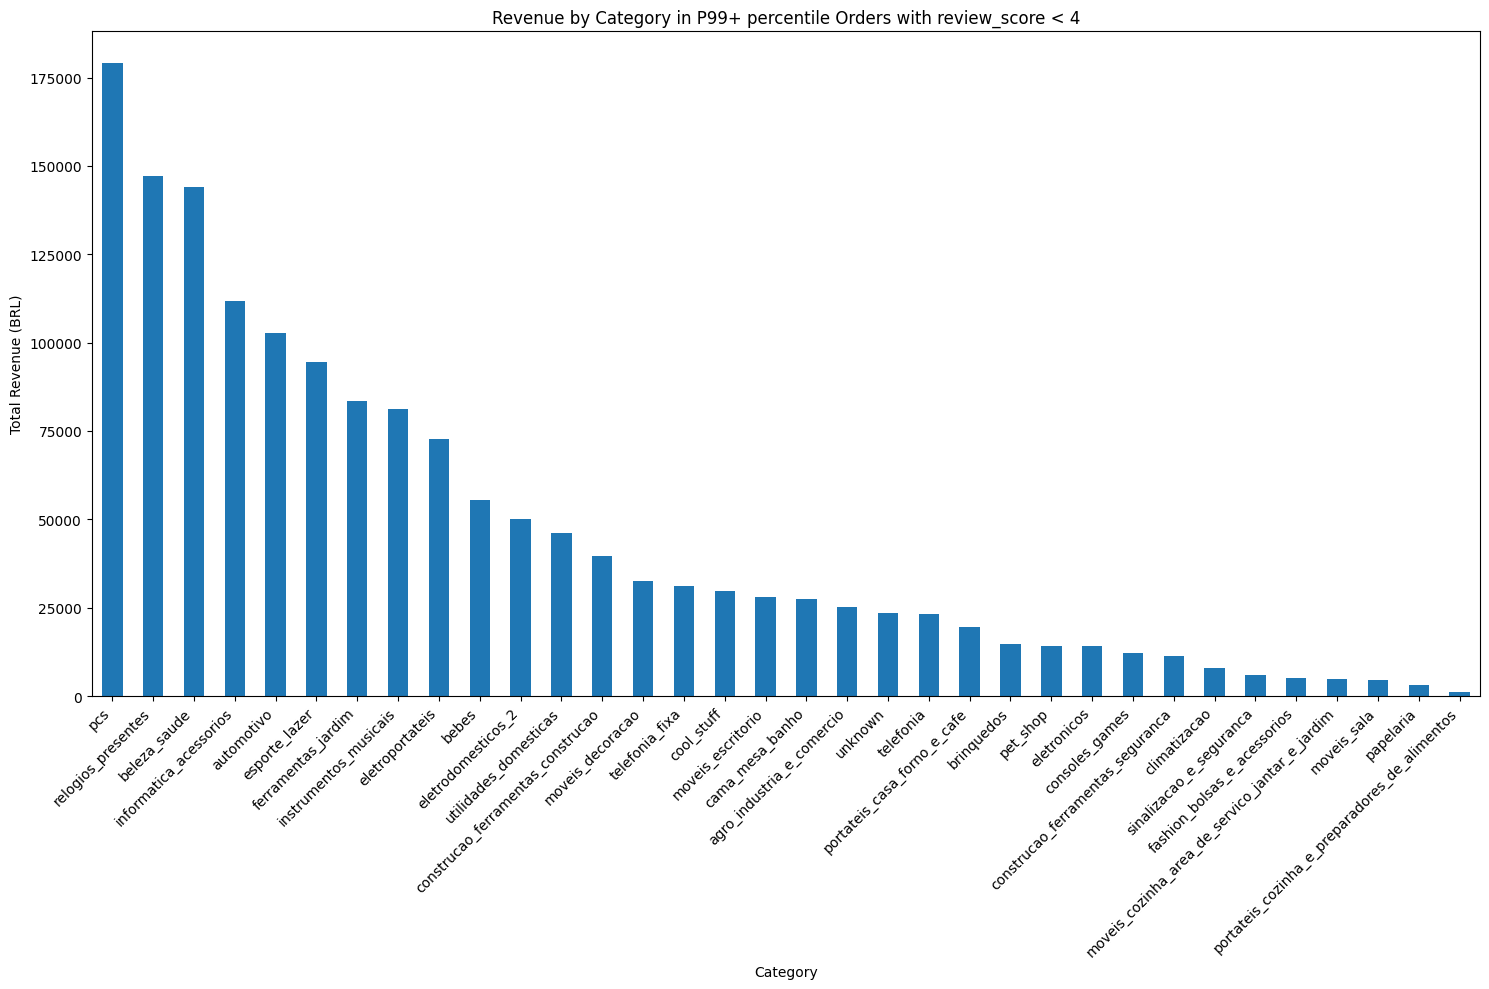

In [90]:
top_category_low_review = list(p99_plus_master[p99_plus_master["review_score"]<4]["category"])

category_revenue = (p99_plus_master[p99_plus_master["category"].isin(top_category_low_review)].groupby("category")["payment_value"].sum()
    .sort_values(ascending=False))

plt.figure(figsize=(15, 10))
category_revenue.plot(kind="bar")

plt.title("Revenue by Category in P99+ percentile Orders with review_score < 4")
plt.xlabel("Category")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Revenue by Category in P99+ percentile Orders with low review_score")

plt.show()

In [91]:
### total revenue generated by 99 percentile orders with review_score < 4

revenue_review_low =p99_plus_master[p99_plus_master["review_score"]<4]["payment_value"].sum()
count_review_low= p99_plus_master[p99_plus_master["review_score"]<4]["payment_value"].count()

print(f" revenue for high value , low review orders : {revenue_review_low: .0f} and count of high value , low review orders : {count_review_low}")



 revenue for high value , low review orders :  398904 and count of high value , low review orders : 229


In [92]:
print(f" average revenue for high value , low review orders : {revenue_review_low/count_review_low:.0f}")

 average revenue for high value , low review orders : 1742


* this shows that even amongst the very high value orders , though the average revenue is mostly almost even for both high and low review score ( taking the scale of high value orders) ,still the high review orders generate a much higher revneue in total

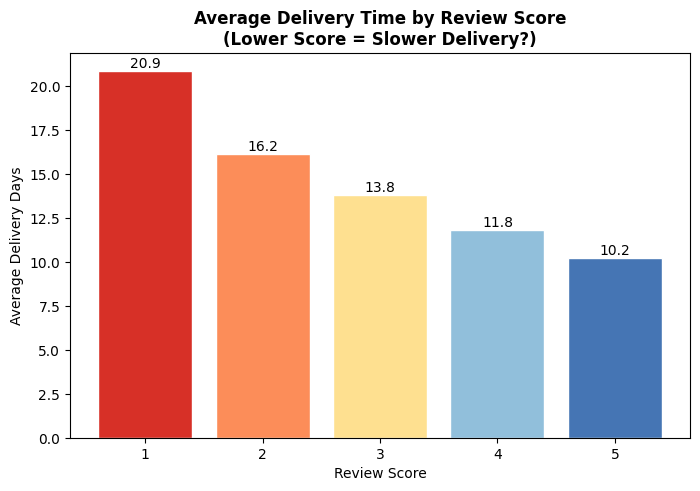

In [96]:

# REVIEW SCORE vs DELIVERY TIME (KEY BUSINESS INSIGHT)

# WHY: If slow delivery correlates with low reviews, you have business evidence
#      that operations (logistics) drives customer satisfaction

review_delivery = master.groupby('review_score')['delivery_days'].mean().reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(review_delivery['review_score'], review_delivery['delivery_days'],
               color=['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4'], edgecolor='white')
plt.title('Average Delivery Time by Review Score\n(Lower Score = Slower Delivery?)', fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
for bar, val in zip(bars, review_delivery['delivery_days']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}', ha='center')

plt.savefig('eda_delivery_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()
# Expected: 1-star reviews have ~20+ avg delivery days; 5-star reviews have ~10-12 days
# This confirms: delivery speed → customer satisfaction → retention

* Hypothesis

Does delivery time affect customer satisfaction (review score)?

* What the chart shows

Customers who gave 1-star reviews waited ~20.9 days on average.
Customers who gave 2-star reviews waited ~16.2 days.
Customers who gave 3-star reviews waited ~13.8 days.
Customers who gave 4-star reviews waited ~11.8 days.
Customers who gave 5-star reviews waited only ~10.2 days on average.
    
* Key Finding

There is a clear negative relationship between delivery time and customer satisfaction:

* As delivery time increases, review scores decrease.

The difference is substantial:

1-star customers waited about twice as long as 5-star customers (20.9 vs 10.2 days).
Every increase in review score is associated with a shorter average delivery time.

* Interpretation

  
-Delivery speed appears to be one of the strongest drivers of customer satisfaction.
-Customers generally tolerate deliveries around 10–12 days and leave high ratings.
-Once delivery times start moving toward 15–20+ days, customer satisfaction drops noticeably.
-This suggests that many negative reviews may be caused by logistics issues rather than product quality.

* Business Recommendations

  
-Focus on reducing deliveries above 15–20 days.
-Track sellers, regions, and product categories with the longest delivery times.
-Prioritize faster shipping for high-value customers and high-demand products.
-Set an operational KPI such as "90% of orders delivered within 15 days."
    
* Business Impact

This is one of the strongest actionable findings in the dataset:

Faster delivery → Higher review scores → Better customer experience → Greater likelihood of future purchases.

In [97]:
## Additional Feature Engineering

In [113]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 96477
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   customer_unique_id             96470 non-null  object        
 3   order_status                   96470 non-null  object        
 4   order_purchase_timestamp       96470 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 7   num_items                      96470 non-null  int64         
 8   item_revenue                   96470 non-null  float64       
 9   avg_item_price                 96470 non-null  float64       
 10  total_freight                  96470 non-null  float64       
 11  category            

## MAKING INTO CUSTOMER LEVEL 

In [114]:
## adding more features : after the initial model( after removi g leakage) gave about only 0.65 AUC-ROC

# 1. FREIGHT RATIO — did the customer pay a lot for shipping relative to product cost?
#  High freight ratio = bad value perception = less likely to return
master['freight_ratio'] = master['total_freight'] / master['payment_value'].replace(0, np.nan)

# 2. DELIVERY DELTA — was delivery early or late vs what was promised?
#    Late delivery = bad experience = less likely to return
#    This is NOT leaky because it's about delivery quality, not when they bought
master['delivery_delta'] = master['delivery_days'] - ((master['order_estimated_delivery_date'] - master['order_purchase_timestamp']).dt.days)
# Positive = delivered late, Negative = delivered early

# 3. REVIEW QUALITY FLAGS — binary signals are more discriminative than the raw score
master['gave_low_review'] = (master['review_score'] <= 2).astype(float)
master['gave_high_review'] = (master['review_score'] >= 4).astype(float)
master['has_review'] = master['review_score'].notna().astype(float)
#  customers who didn't bother to review at all may behave differently from those who actively gave 5 stars or 1 star


In [115]:
# WHY: Right now, master has one row per ORDER. ML for churn model needs one row per CUSTOMER. We aggregate all orders per customer into summary statistics.
# Readjusting/Remaking to enhance features
# Reference date = last date in dataset (used for recency calculation)

reference_date = master['order_purchase_timestamp'].max()
print(f"Reference date for recency calculation: {reference_date.date()}")

customer_features = master.groupby('customer_unique_id').agg(
    # Volume metrics
    total_orders=('order_id', 'nunique'),
    total_spend=('payment_value', 'sum'),
    avg_order_value=('payment_value', 'mean'),
    max_order_value=('payment_value', 'max'),
    min_order_value=('payment_value', 'min'),

    # Time metrics
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max'),

    # Experience metrics
    avg_review_score=('review_score', 'mean'),
    min_review_score=('review_score', 'min'),
    avg_delivery_days=('delivery_days', 'mean'),
    pct_on_time=('on_time_delivery', 'mean'),

    # Product diversity
    favorite_category=('category', lambda x: x.mode().iloc[0]),
    num_categories=('category', 'nunique'),

    # Geography
    state=('customer_state', 'first'),

     # Freight Ratio 
    avg_freight_ratio=('freight_ratio', 'mean'),

    # Delivery Experience
    avg_delivery_delta=('delivery_delta', 'mean'),   # positive = consistently late

    # Review Bins
    gave_low_review=('gave_low_review', 'max'),       # ever gave a low review?
    gave_high_review=('gave_high_review', 'max'),
    has_review=('has_review', 'max'),
).reset_index()

print(f"\nCustomer features table shape: {customer_features.shape}")


Reference date for recency calculation: 2018-08-29

Customer features table shape: (93350, 20)


In [116]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93350 non-null  object        
 1   total_orders        93350 non-null  int64         
 2   total_spend         93350 non-null  float64       
 3   avg_order_value     93350 non-null  float64       
 4   max_order_value     93350 non-null  float64       
 5   min_order_value     93350 non-null  float64       
 6   first_purchase      93350 non-null  datetime64[ns]
 7   last_purchase       93350 non-null  datetime64[ns]
 8   avg_review_score    92747 non-null  float64       
 9   min_review_score    92747 non-null  float64       
 10  avg_delivery_days   93350 non-null  float64       
 11  pct_on_time         93350 non-null  float64       
 12  favorite_category   93350 non-null  object        
 13  num_categories      93350 non-null  int64     

In [117]:
master["customer_unique_id"].nunique()    # this confirms that customer_features has one row per unique customer 
                                        # now we are customer - level data

93350

### Deriving Additional Features 

In [118]:
reference_date

Timestamp('2018-08-29 15:00:37')

In [119]:
# DERIVING ADDITIONAL FEATURES FROM EXISTING ONES

# Recency: days since last purchase from reference date
customer_features['recency_days'] = (reference_date - customer_features['last_purchase']).dt.days

# Customer lifetime: how long have they been a customer (in days)?
customer_features['customer_age_days'] = (customer_features['last_purchase'] - customer_features['first_purchase']).dt.days + 1

# Average days between orders (for customers with multiple orders)
# if total_orders = 1, customer_age_days = 0
'''customer_features['avg_days_between_orders'] = np.where(customer_features['total_orders'] > 1,
    customer_features['customer_age_days'] / (customer_features['total_orders'] - 1),
    customer_features['recency_days'])  # if single order, recency IS their gap)'''

    # NOTE : fixing the mistake , as putting 'recency days' for customers having single order will leak the info. for the churn model , instead 

customer_features['avg_days_between_orders'] = np.where(
    customer_features['total_orders'] > 1,
    customer_features['customer_age_days'] / (customer_features['total_orders'] - 1),
    np.nan
)    # since almost 94% of the customers did not have more tha 1 order, I cannot impute any median, etc. value for the missing 'avg_days_between_orders'

# So i am making a new column = "has_repeat_orders"

customer_features["has_repeat_orders"] = (customer_features["total_orders"] > 1).astype(int)

# Order value range (max - min): measures spending consistency
customer_features['order_value_range'] = np.where(customer_features['total_orders'] > 1,
                            (customer_features['max_order_value'] - customer_features['min_order_value']),customer_features['max_order_value'])

# Spend per day (engagement intensity)
customer_features['spend_per_active_day'] = np.where(customer_features['customer_age_days'] > 0,customer_features['total_spend'] / customer_features['customer_age_days'],
    customer_features['total_spend'])  # single-day customer)


In [120]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       93350 non-null  object        
 1   total_orders             93350 non-null  int64         
 2   total_spend              93350 non-null  float64       
 3   avg_order_value          93350 non-null  float64       
 4   max_order_value          93350 non-null  float64       
 5   min_order_value          93350 non-null  float64       
 6   first_purchase           93350 non-null  datetime64[ns]
 7   last_purchase            93350 non-null  datetime64[ns]
 8   avg_review_score         92747 non-null  float64       
 9   min_review_score         92747 non-null  float64       
 10  avg_delivery_days        93350 non-null  float64       
 11  pct_on_time              93350 non-null  float64       
 12  favorite_category        93350 n

In [121]:
# THE CHURN LABEL (TARGET VARIABLE)
# churned = 1 (customer has left), not_churned = 0 (still active).
# For Olist data (which covers ~2 years), 180 days is a reasonable threshold.

CHURN_DAYS = 180

customer_features['churned'] = (
    customer_features['recency_days'] > CHURN_DAYS
).astype(int)

churn_rate = customer_features['churned'].mean()
print(f"Churn threshold: {CHURN_DAYS} days of inactivity")
print(f"Churned customers: {customer_features['churned'].sum():,} ({churn_rate*100:.1f}%)")
print(f"Active customers: {(customer_features['churned']==0).sum():,} ({(1-churn_rate)*100:.1f}%)")
# Expected: ~60-70% churn rate (Olist has very low repeat purchase rates)

Churn threshold: 180 days of inactivity
Churned customers: 55,004 (58.9%)
Active customers: 38,346 (41.1%)


In [122]:
customer_features.head()

,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,first_purchase,last_purchase,avg_review_score,min_review_score,...,gave_low_review,gave_high_review,has_review,recency_days,customer_age_days,avg_days_between_orders,has_repeat_orders,order_value_range,spend_per_active_day,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,5.0,...,0.0,1.0,1.0,111,1,NaN,0,141.90,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,4.0,...,0.0,1.0,1.0,114,1,NaN,0,27.19,27.19,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,3.0,...,0.0,0.0,1.0,536,1,NaN,0,86.22,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,4.0,...,0.0,1.0,1.0,320,1,NaN,0,43.62,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,5.0,...,0.0,1.0,1.0,287,1,NaN,0,196.89,196.89,1


In [123]:
customer_features.to_csv('customer_features.csv', index=False)
print(f"Saved customer features: {customer_features.shape}")
print(f"\nFinal feature table columns:")
for col in customer_features.columns:
    print(f"  {col}")

Saved customer features: (93350, 27)

Final feature table columns:
  customer_unique_id
  total_orders
  total_spend
  avg_order_value
  max_order_value
  min_order_value
  first_purchase
  last_purchase
  avg_review_score
  min_review_score
  avg_delivery_days
  pct_on_time
  favorite_category
  num_categories
  state
  avg_freight_ratio
  avg_delivery_delta
  gave_low_review
  gave_high_review
  has_review
  recency_days
  customer_age_days
  avg_days_between_orders
  has_repeat_orders
  order_value_range
  spend_per_active_day
  churned


In [124]:
customer_features[
    (customer_features["first_purchase"].dt.year == 2016)
    &
    (customer_features["first_purchase"].dt.month.isin([9, 11, 12]))
]

,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,first_purchase,last_purchase,avg_review_score,min_review_score,...,gave_low_review,gave_high_review,has_review,recency_days,customer_age_days,avg_days_between_orders,has_repeat_orders,order_value_range,spend_per_active_day,churned
47877,830d5b7aaa3b6f1e9ad63703bec97d23,1,143.46,143.46,143.46,143.46,2016-09-15 12:16:38,2016-09-15 12:16:38,1.0,1.0,...,1.0,0.0,1.0,713,1,NaN,0,143.46,143.460000,1
90387,f7b981e8a280e455ac3cbe0d5d171bd1,2,39.24,19.62,19.62,19.62,2016-12-23 23:16:47,2017-01-05 11:56:06,5.0,5.0,...,0.0,1.0,1.0,601,13,13.0,1,0.00,3.018462,1


In [125]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       93350 non-null  object        
 1   total_orders             93350 non-null  int64         
 2   total_spend              93350 non-null  float64       
 3   avg_order_value          93350 non-null  float64       
 4   max_order_value          93350 non-null  float64       
 5   min_order_value          93350 non-null  float64       
 6   first_purchase           93350 non-null  datetime64[ns]
 7   last_purchase            93350 non-null  datetime64[ns]
 8   avg_review_score         92747 non-null  float64       
 9   min_review_score         92747 non-null  float64       
 10  avg_delivery_days        93350 non-null  float64       
 11  pct_on_time              93350 non-null  float64       
 12  favorite_category        93350 n

In [126]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       93350 non-null  object        
 1   total_orders             93350 non-null  int64         
 2   total_spend              93350 non-null  float64       
 3   avg_order_value          93350 non-null  float64       
 4   max_order_value          93350 non-null  float64       
 5   min_order_value          93350 non-null  float64       
 6   first_purchase           93350 non-null  datetime64[ns]
 7   last_purchase            93350 non-null  datetime64[ns]
 8   avg_review_score         92747 non-null  float64       
 9   min_review_score         92747 non-null  float64       
 10  avg_delivery_days        93350 non-null  float64       
 11  pct_on_time              93350 non-null  float64       
 12  favorite_category        93350 n

In [127]:
# exploring whether  some categories are inherently consumable
# These tend to have higher repeat purchase rates regardless of experience like consumable_categories ='food_drink', 'health_beauty', 'baby', 'pet_shop',
#    'perfumaria', 'bebes', 'alimentos_bebidas' ,etc.



master.info()



<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 96477
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   customer_unique_id             96470 non-null  object        
 3   order_status                   96470 non-null  object        
 4   order_purchase_timestamp       96470 non-null  datetime64[ns]
 5   order_delivered_customer_date  96470 non-null  datetime64[ns]
 6   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 7   num_items                      96470 non-null  int64         
 8   item_revenue                   96470 non-null  float64       
 9   avg_item_price                 96470 non-null  float64       
 10  total_freight                  96470 non-null  float64       
 11  category            

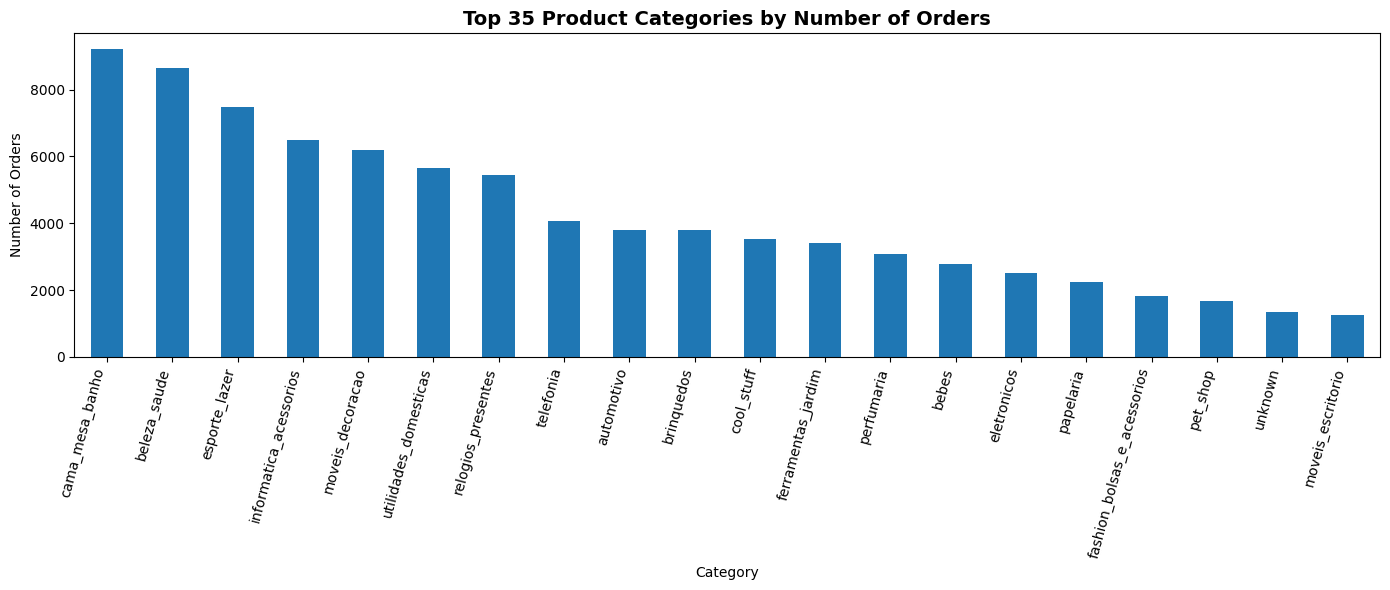

In [128]:
import matplotlib.pyplot as plt

# Top 35 categories by order count
top35 = (
    master["category"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,6))
top35.plot(kind="bar")

plt.title("Top 35 Product Categories by Number of Orders", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

In [129]:
### adding more features 

In [130]:
# ── MEDIUM IMPACT FEATURES ──────────────────────────────────────────

# 1. CONSUMABLE CATEGORY FLAG
# Based on your actual top-20 categories — only these 5 are repeat-purchase by nature
# Everything else (furniture, phones, electronics, sports gear) is inherently one-time
consumable_categories = [
    'beleza_saude',      # beauty & health — repeat by nature
    'perfumaria',        # perfumery — repeat by nature
    'bebes',             # baby products — diapers, formula etc.
    'pet_shop',          # pet food & supplies
    'papelaria'          # stationery — arguable but plausible repeat
]

customer_features['is_consumable_category'] = (
    customer_features['favorite_category'].isin(consumable_categories)
).astype(int)

# Quick sanity check — how many customers fall in consumable categories?
print(customer_features['is_consumable_category'].value_counts())
print(f"Consumable category customers: {customer_features['is_consumable_category'].mean()*100:.1f}%")


# 2. ONE-TIME PURCHASE CATEGORY FLAG (complement of above — explicitly label the other end)
# These categories almost never generate repeat purchases regardless of experience
one_time_categories = [
    'moveis_decoracao',         # furniture
    'cama_mesa_banho',          # bed/bath — replaced infrequently
    'informatica_acessorios',   # computer accessories
    'eletronicos',              # electronics
    'telefonia',                # phones
    'moveis_escritorio',        # office furniture
    'relogios_presentes'        # watches & gifts
]

customer_features['is_one_time_category'] = (
    customer_features['favorite_category'].isin(one_time_categories)
).astype(int)


# 3. SPEND TIER — captures non-linear spend effects better than raw total_spend
# pd.qcut divides into 5 equal-population buckets based on actual spend distribution
customer_features['spend_tier'] = pd.qcut(
    customer_features['total_spend'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'          # handles edge case if many customers have same spend value
).astype(int)


# 4. REVIEW BINARY FLAGS — more discriminative than the raw 1-5 score
customer_features['gave_low_review'] = (
    customer_features['avg_review_score'] <= 2
).astype(float)

customer_features['gave_high_review'] = (
    customer_features['avg_review_score'] >= 4
).astype(float)

customer_features['review_missing'] = (
    customer_features['avg_review_score'].isna()
).astype(int)


# ── VERIFY ───────────────────────────────────────────────────────────
new_features = [
    'is_consumable_category', 'is_one_time_category',
    'spend_tier', 'gave_low_review', 'gave_high_review', 'review_missing'
]

print("\nNew features added:")
print(customer_features[new_features].describe().round(3))

# Cross-check: do consumable category customers churn less?
# If yes, the feature has real signal
print("\nChurn rate by category type:")
print(customer_features.groupby('is_consumable_category')['churned'].mean().round(3))
print(customer_features.groupby('is_one_time_category')['churned'].mean().round(3))

is_consumable_category
0    75395
1    17955
Name: count, dtype: int64
Consumable category customers: 19.2%

New features added:
       is_consumable_category  is_one_time_category  spend_tier  \
count               93350.000             93350.000   93350.000   
mean                    0.192                 0.363       3.000   
std                     0.394                 0.481       1.414   
min                     0.000                 0.000       1.000   
25%                     0.000                 0.000       2.000   
50%                     0.000                 0.000       3.000   
75%                     0.000                 1.000       4.000   
max                     1.000                 1.000       5.000   

       gave_low_review  gave_high_review  review_missing  
count        93350.000         93350.000       93350.000  
mean             0.126             0.782           0.006  
std              0.332             0.413           0.080  
min              0.000         

In [131]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       93350 non-null  object        
 1   total_orders             93350 non-null  int64         
 2   total_spend              93350 non-null  float64       
 3   avg_order_value          93350 non-null  float64       
 4   max_order_value          93350 non-null  float64       
 5   min_order_value          93350 non-null  float64       
 6   first_purchase           93350 non-null  datetime64[ns]
 7   last_purchase            93350 non-null  datetime64[ns]
 8   avg_review_score         92747 non-null  float64       
 9   min_review_score         92747 non-null  float64       
 10  avg_delivery_days        93350 non-null  float64       
 11  pct_on_time              93350 non-null  float64       
 12  favorite_category        93350 n

In [132]:
customer_features.to_csv("customer_features.csv")